# Data Obfuscationa and security using Multi algorith encryption and Audio Steganography

In [1]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import importlib
import Code2
importlib.reload(Code2)
from Code2 import *

import numpy as np
import wave
import matplotlib.pyplot as plt
from math import ceil

# Encrypt and Decrypt

In [10]:
PHASE_ENCODE_FREQ = 5000  # Fixed frequency for phase modifications (Hz)
CHUNK_SIZE = 1024          # STFT window size
HOP_LENGTH = CHUNK_SIZE // 4 # IMPORTANT: Overlapping fixes boundary noise (25% overlap)
LSB_LAYERS = 1             # Fixed number of LSB layers for XOR embedding
ECC_LENGTH = 16            # No. of bytes for RS Error correction

DEBUG_OUT        = True
PLAINTEXT        = b"Data Obfuscation and Security using Multi-Algorithm Encryption and Audio Steganography by Mohammed Emaan"
K1               = b"BITS Pilani Dubai Campus"
COVER_AUDIO_PATH = "pocketful trimmed.wav"
OUTPUT_PATH      = "stego.wav"

In [11]:
embed(PLAINTEXT, K1, COVER_AUDIO_PATH, OUTPUT_PATH,
    freq=PHASE_ENCODE_FREQ,
    chunk_size=CHUNK_SIZE,
    hop_length=HOP_LENGTH,
    lsb_layers=LSB_LAYERS,
    ecc_length=ECC_LENGTH,
    debug_out=DEBUG_OUT,
)

Embed:
  encrypted_k2_encoded: 535d:0a58:1525:baac:8b0c:f1e3:b891:9b1c:b65b:ed34:0de7:f86a:6a8d:7f8c:04f6:3f9a:2acb:e40f:a487:f9ed:7f81:484e:ed02:6306:2f62:dbab:c33f:a1ed:62d6:7830:cd2f:22b0
  ct2_encoded         : 4fdd:378d:ca2d:1f14:fc2e:2625:aec0:44ad:27cc:87dc:a160:9f3e:a0a6:bfd2:9f97:b158:03ed:eb76:20c7:ada6:3c4e:0ac5:9eef:fd73:c53a:e589:0ba3:3ebe:3280:8692:8114:245c:005d:169c:84b0:a531:5b4f:81ec:c711:f2d5:b6b7:d56d:5a4c:03f4:cbee:8add:7b68:23db:0b92:4170:3d1f:b432:2d4d:df72:db7e:7b2a:7451:fae4:17f4:92a3:1f01:36f6:e25c:9ff8 



In [12]:
decoded = extract(OUTPUT_PATH, K1,
    freq=PHASE_ENCODE_FREQ,
    chunk_size=CHUNK_SIZE,
    hop_length=HOP_LENGTH,
    lsb_layers=LSB_LAYERS,
    ecc_length=ECC_LENGTH,
    debug_out=DEBUG_OUT,
)
print(decoded)

Extract:
  encrypted_k2_encoded: 535d:0a58:1525:baac:8b0c:f1e3:b891:9b1c:b65b:ed34:0de7:f86a:6a8d:7f8c:04f6:3f9a:2acb:e40f:a487:f9ed:7f81:484e:ed02:6306:2f62:dbab:c33f:a1ed:62d6:7830:cd2f:22b0
  ct2_encoded         : 4fdd:378d:ca2d:1f14:fc2e:2625:aec0:44ad:27cc:87dc:a160:9f3e:a0a6:bfd2:9f97:b158:03ed:eb76:20c7:ada6:3c4e:0ac5:9eef:fd73:c53a:e589:0ba3:3ebe:3280:8692:8114:245c:005d:169c:84b0:a531:5b4f:81ec:c711:f2d5:b6b7:d56d:5a4c:03f4:cbee:8add:7b68:23db:0b92:4170:3d1f:b432:2d4d:df72:db7e:7b2a:7451:fae4:17f4:92a3:1f01:36f6:e25c:9ff8 

b'Data Obfuscation and Security using Multi-Algorithm Encryption and Audio Steganography by Mohammed Emaan'


# Plot

In [6]:
with wave.open(COVER_AUDIO_PATH, 'rb') as cover_wav:
    cover_sample_rate = cover_wav.getframerate()
    cover_samples = np.frombuffer(cover_wav.readframes(cover_wav.getnframes()), dtype=np.int16)
with wave.open(OUTPUT_PATH, 'rb') as output_wav:
    output_sample_rate = output_wav.getframerate()
    output_samples = np.frombuffer(output_wav.readframes(output_wav.getnframes()), dtype=np.int16)

assert len(cover_samples) == len(output_samples)
error_samples = abs(cover_samples - output_samples)

# Time axes in seconds
y_ticks = np.arange(-32768, 32768+1, 8192)
y_ticks_positive = np.arange(0, 32768+1, 8192)

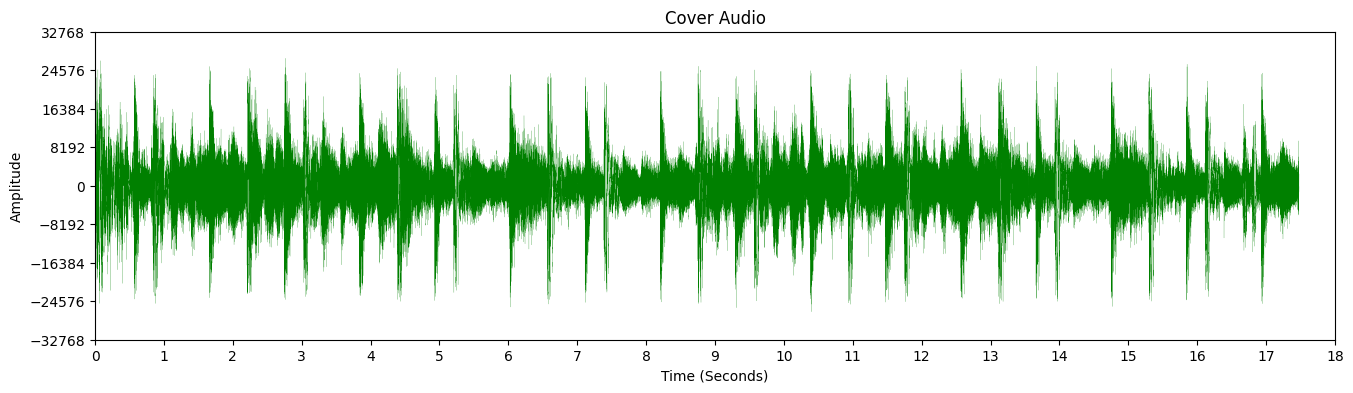

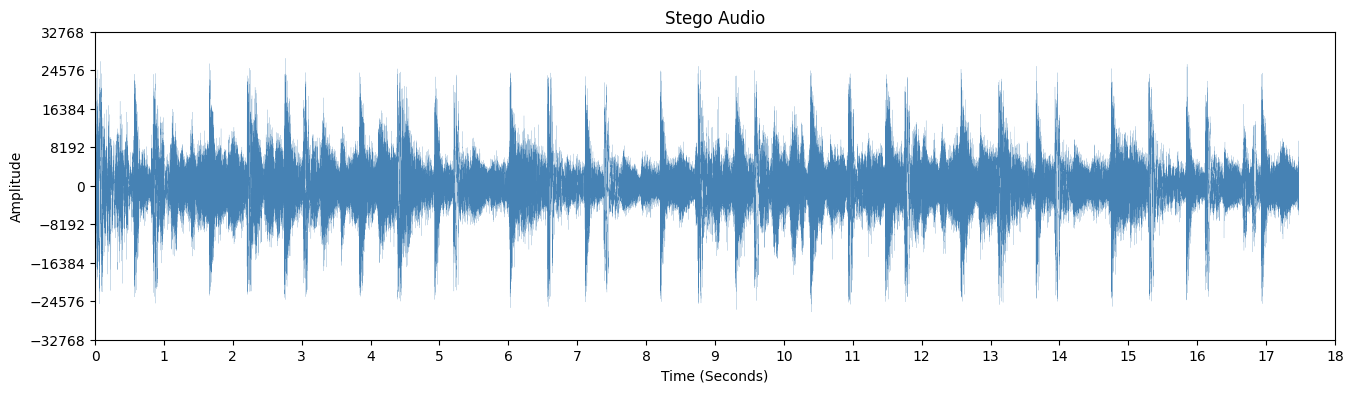

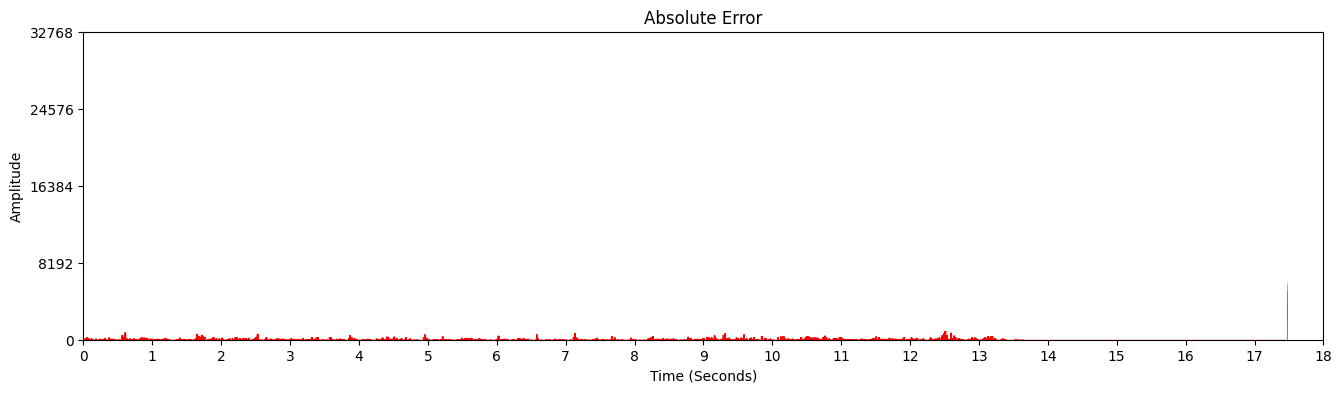

In [7]:
LINE_WIDTH = 0.1
X_SECONDS_STEP = 1.0

x_seconds = np.arange(len(cover_samples)) / cover_sample_rate
x_seconds_ticks = np.arange(0, ceil(max(x_seconds))+1, X_SECONDS_STEP)

plt.figure(figsize=(16, 4))
plt.plot(x_seconds, cover_samples, color='green', linewidth=LINE_WIDTH)
plt.title('Cover Audio')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude')
plt.xlim(0, max(x_seconds))
plt.ylim(-32768, 32767)
plt.xticks(x_seconds_ticks)
plt.yticks(y_ticks)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x_seconds, output_samples, color='steelblue', linewidth=LINE_WIDTH)
plt.title('Stego Audio')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude')
plt.xlim(0, max(x_seconds))
plt.ylim(-32768, 32767)
plt.xticks(x_seconds_ticks)
plt.yticks(y_ticks)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x_seconds, error_samples, color='red', linewidth=LINE_WIDTH)
plt.title('Absolute Error')
plt.xlabel('Time (Seconds)')
plt.ylabel('Amplitude')
plt.xlim(0, max(x_seconds))
plt.ylim(0, 32767)
plt.xticks(x_seconds_ticks)
plt.yticks(y_ticks_positive)
plt.show()


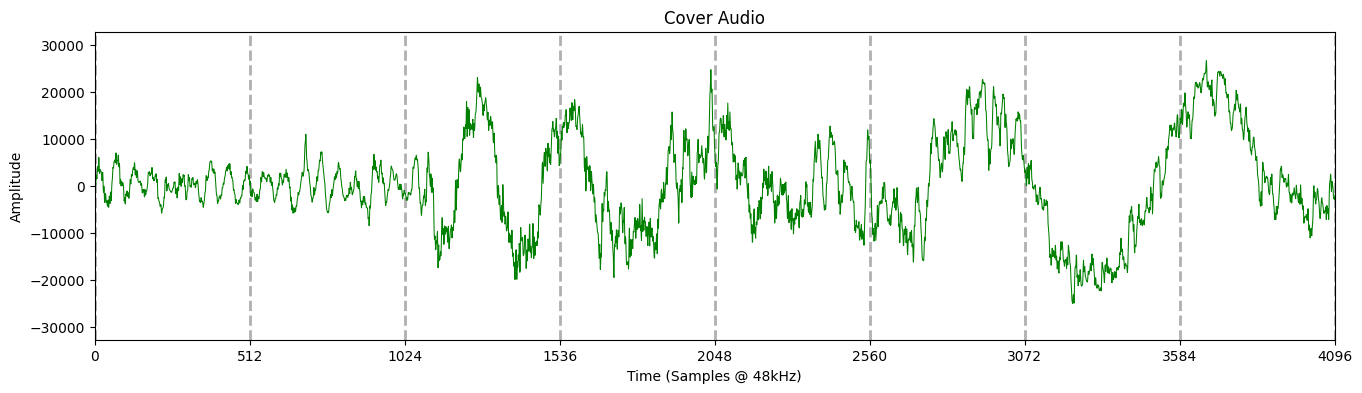

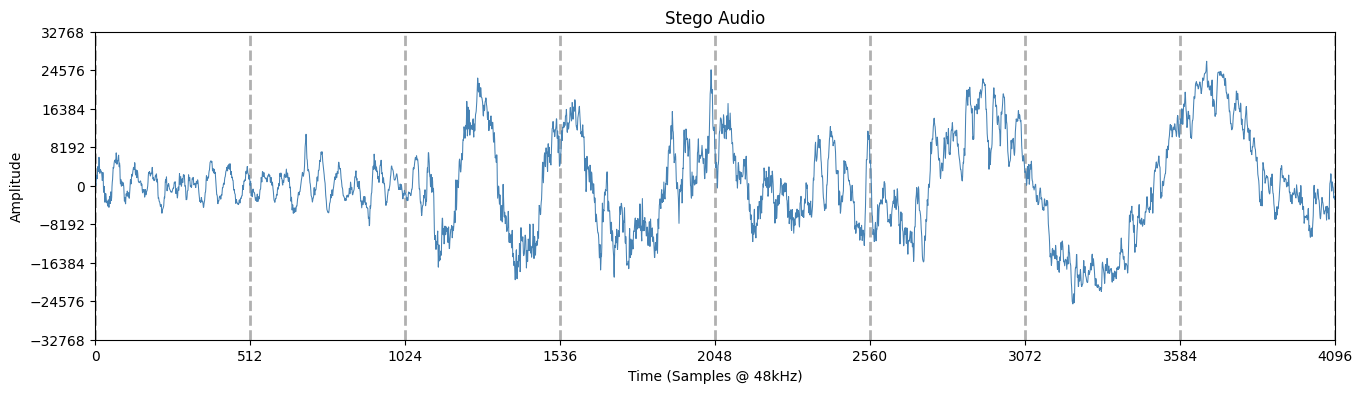

In [8]:
LINE_WIDTH = .75
LENGTH = 1024*4
STEP = 512

x_samples = np.arange(len(cover_samples))
x_samples_ticks = np.arange(0, LENGTH+1, STEP)

plt.figure(figsize=(16, 4))
plt.plot(x_samples, cover_samples, color='green', linewidth=LINE_WIDTH)
plt.title('Cover Audio')
plt.xlabel('Time (Samples @ 48kHz)')
plt.ylabel('Amplitude')
plt.xlim(0, LENGTH)
plt.ylim(-32768, 32767)
plt.xticks(x_samples_ticks)
plt.ylim(-32768, 32767)
plt.grid(axis='x', which='major', linestyle='--', linewidth=2)
plt.grid(axis='x', which='minor', linestyle='--', linewidth=1)
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(x_samples, output_samples, color='steelblue', linewidth=LINE_WIDTH)
plt.title('Stego Audio')
plt.xlabel('Time (Samples @ 48kHz)')
plt.ylabel('Amplitude')
plt.xlim(0, LENGTH)
plt.ylim(-32768, 32767)
plt.xticks(x_samples_ticks)
plt.yticks(y_ticks)
plt.grid(axis='x', which='major', linestyle='--', linewidth=2)
plt.show()

# Decrypt

In [13]:
# The password you used to hide the message
K1 = b"BITS Pilani Dubai Campus"

# Call the extract function to reverse the process
secret_bytes = extract(
    stego_audio_path="stego.wav",  # The file containing the hidden data
    k1=K1,
    freq=PHASE_ENCODE_FREQ,
    chunk_size=CHUNK_SIZE,
    hop_length=HOP_LENGTH,
    lsb_layers=LSB_LAYERS,
    ecc_length=ECC_LENGTH,
    debug_out=False
)

# Convert the bytes back into readable text
print("THE SECRET MESSAGE IS:")
print(secret_bytes.decode('utf-8'))

THE SECRET MESSAGE IS:
Data Obfuscation and Security using Multi-Algorithm Encryption and Audio Steganography by Mohammed Emaan
